In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False) 

X, y = mnist.data, mnist.target
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

Try to build a classifier for the MNIST dataset that achieves over 97% accuracy
on the test set. Hint: the KNeighborsClassifier works quite well for this task;
you just need to find good hyperparameter values (try a grid search on the
weights and n_neighbors hyperparameters).

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn_clf = KNeighborsClassifier()

grid = {
    'n_neighbors': [3, 8],
    'weights': ['uniform', 'distance'],
}

knn_search = GridSearchCV(knn_clf, grid, scoring='accuracy', cv=3)
knn_search.fit(X_train, y_train)

In [8]:
knn_search.best_params_

{'n_neighbors': 3, 'weights': 'distance'}

In [9]:
from sklearn.metrics import accuracy_score

best_est = knn_search.best_estimator_
y_pred = best_est.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.9717


In [6]:
knn_clf = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_clf.fit(X_train, y_train)
y_pred = knn_clf.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.9717


Write a function that can shift an MNIST image in any direction (left, right, up,
or down) by one pixel.6 Then, for each image in the training set, create four
shifted copies (one per direction) and add them to the training set. Finally, train
your best model on this expanded training set and measure its accuracy on the
test set. You should observe that your model performs even better now! This
technique of artificially growing the training set is called data augmentation or
training set expansion.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

def move_one_pixel(image_data, direction):
    image_pixels = image_data.reshape(28, 28)

    match direction:
        case 'up': image_pixels = np.roll(image_pixels, -1, axis=0)
        case 'down': image_pixels = np.roll(image_pixels, 1, axis=0)
        case 'right': image_pixels = np.roll(image_pixels, 1, axis=1)
        case 'left': image_pixels = np.roll(image_pixels, -1, axis=1)
        case _: raise ValueError('invalid direction')

    return image_pixels.flatten()

some_digit = X[50000]
plot_digit(some_digit)
plt.show()

plot_digit(move_one_pixel(some_digit, 'up'))
plt.show()


In [4]:
X_shifted_train = X_train.copy()

for dir in ('left', 'right', 'up', 'down'):
    one_dir_digits = np.empty_like(X_train)
    for i, sample in enumerate(X_train):
        one_dir_digits[i] = move_one_pixel(sample, dir)

    X_shifted_train = np.vstack([X_shifted_train, one_dir_digits])

y_shifted_train = np.tile(y_train, 5)

In [6]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_clf.fit(X_shifted_train, y_shifted_train)
y_pred = knn_clf.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.9763


Tackle the Titanic dataset. A great place to start is on Kaggle. Alternatively, you
can download the data from https://homl.info/titanic.tgz and unzip this tarball
like you did for the housing data in Chapter 2. This will give you two CSV files,
train.csv and test.csv, which you can load using pandas.read_csv(). The goal
is to train a classifier that can predict the Survived column based on the other
columns.

In [26]:
import pandas as pd
data = pd.read_csv('../../datasets/titanic/train.csv')

y_train = data['Survived'].copy()
X_train = data.drop(columns='Survived')

In [27]:
data.info()
data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen 'Carrie'",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

def age_bucketize(X):
    X = X.flatten()
    buckets = pd.cut(X, bins=[0, 12, 18, 35, 60, 100],
                     labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])
    return buckets.to_numpy().reshape(-1, 1)

def has_cabin(X):
    X = X.to_numpy().flatten()
    return ~pd.isna(X).reshape(-1, 1)

age_pipeline = Pipeline([
    ('impute', IterativeImputer(initial_strategy='median')),
    ('bucketizing', FunctionTransformer(age_bucketize)),
    ('encoding', OneHotEncoder())
]) 

embarked_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder())
])

def get_familysize(X):
    X = X.values
    return X.sum(axis=1).reshape(-1, 1)

most_common_titles = {'Mr', 'Miss', 'Mrs', 'Master'}
def set_titles(X):
    X = X['Name']
    titles = X.apply(lambda x: x.split(',')[1].split('.')[0].strip())
    return titles.apply(lambda x: x if x in most_common_titles else 'Other').to_numpy().reshape(-1, 1)

title_pipeline = Pipeline([
    ('set_titles', FunctionTransformer(set_titles)),
    ('encode', OneHotEncoder())
])

preprocessing = ColumnTransformer([
    ('encoding', OneHotEncoder(), ['Pclass', 'Sex']),
    ('age', age_pipeline, ['Age']),
    ('cabin', FunctionTransformer(has_cabin), ['Cabin']),
    ('embarked', embarked_pipeline, ['Embarked']),
    ('fare', StandardScaler(), ['Fare']),
    ('familysize', FunctionTransformer(get_familysize), ['SibSp', 'Parch']),
    ('title', title_pipeline, ['Name']),
])

forest_model = RandomForestClassifier(random_state=42)
forest_clf = Pipeline([
    ('preprocessing', preprocessing),
    ('forest', forest_model)
])

In [57]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(forest_clf, X_train, y_train, cv=3, scoring='roc_auc')
ser_scores = pd.Series(scores)
ser_scores.describe()

count    3.000000
mean     0.837951
std      0.039519
min      0.799971
25%      0.817503
50%      0.835035
75%      0.856941
max      0.878847
dtype: float64

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'forest__n_estimators': [80, 100],
    'forest__max_depth': [3, 5],
    'forest__min_samples_split': [5, 7],
    'forest__min_samples_leaf': [1, 2, 3],
}

grid_search = GridSearchCV(forest_clf, param_grid, cv=3, scoring='roc_auc')
grid_search.fit(X_train, y_train)

In [71]:
print(grid_search.best_score_)
print(grid_search.best_params_)
pd.DataFrame(grid_search.cv_results_).sort_values('mean_test_score', ascending=False).head()

0.8695874476720032
{'forest__max_depth': 5, 'forest__min_samples_leaf': 1, 'forest__min_samples_split': 5, 'forest__n_estimators': 80}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_forest__max_depth,param_forest__min_samples_leaf,param_forest__min_samples_split,param_forest__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
12,0.209529,0.000539,0.027441,0.001332,5,1,5,80,"{'forest__max_depth': 5, 'forest__min_samples_...",0.837144,0.877265,0.894353,0.869587,0.023978,1
13,0.262885,0.002401,0.028987,0.000274,5,1,5,100,"{'forest__max_depth': 5, 'forest__min_samples_...",0.838606,0.878343,0.891238,0.869396,0.022399,2
17,0.286412,0.007250,0.031572,0.002581,5,2,5,100,"{'forest__max_depth': 5, 'forest__min_samples_...",0.838678,0.880405,0.888170,0.869084,0.021733,3
14,0.214735,0.001404,0.027878,0.001013,5,1,7,80,"{'forest__max_depth': 5, 'forest__min_samples_...",0.835251,0.878439,0.892772,0.868821,0.024448,4
20,0.223705,0.019466,0.028934,0.002893,5,3,5,80,"{'forest__max_depth': 5, 'forest__min_samples_...",0.834795,0.879614,0.891262,0.868557,0.024342,5


In [69]:
X_test = pd.read_csv('../../datasets/titanic/test.csv')
X_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [ ]:
y_test_pred = grid_search.best_estimator_.predict(X_test)
y_test_pred

In [73]:
X_test['Pred Survived'] = y_test_pred
X_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pred Survived
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,0
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,1
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,0


Build a spam classifier (a more challenging exercise):

    a. Download examples of spam and ham from Apache SpamAssassin’s public datasets.

    b. Unzip the datasets and familiarize yourself with the data format.

    c. Split the data into a training set and a test set. 

    d. Write a data preparation pipeline to convert each email into a feature vector. Your preparation pipeline should transform an email into a (sparse) vector that indicates the presence or absence of each possible word. For example, if all emails only ever contain four words, “Hello”, “how”, “are”, “you”, then the email “Hello you Hello Hello you” would be converted into a vector [1, 0, 0, 1] (meaning [“Hello” is present, “how” is absent, “are” is absent, “you” is present]), or [3, 0, 0, 2] if you prefer to count the number of occurrences of each word. You may want to add hyperparameters to your preparation pipeline to control whether or not to strip off email headers, convert each email to lowercase, remove punctuation, replace all URLs with “URL”, replace all numbers with “NUMBER”, or even perform stemming (i.e., trim off word endings; there are Python libraries available to do this).

    e. Finally, try out several classifiers and see if you can build a great spam classi‐ fier, with both high recall and high precision.

In [7]:
import os 
import numpy as np

def get_files(dir):
    def gen():
        for f_name in os.listdir(dir):
            path = os.path.join(dir, f_name)
            with open(path, errors="ignore") as file:
                yield file.read()

    return np.fromiter(gen(), np.object_)


print(os.listdir('../../datasets/emails'))

['hard_ham', 'spam', 'easy_ham']


In [8]:
spam = get_files('../../datasets/emails/spam')
easy_ham = get_files('../../datasets/emails/easy_ham')
hard_ham = get_files('../../datasets/emails/hard_ham')

In [9]:
X = np.concatenate([spam, easy_ham, hard_ham])
y = np.array([1, 0])
y = np.repeat(y, [len(spam), len(easy_ham) + len(hard_ham)])

print(len(X), len(y))

3302 3302


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42)

In [11]:
import pandas as pd

y_train_stratify = pd.Series(y_train).value_counts()
y_test_stratify = pd.Series(y_test).value_counts()

print(y_train_stratify / y_train_stratify.sum())
print(y_test_stratify / y_test_stratify.sum())

0    0.848164
1    0.151836
Name: count, dtype: float64
0    0.848714
1    0.151286
Name: count, dtype: float64


In [12]:
X_train[:2]

array(['From fork-admin@xent.com  Fri Sep  6 11:41:57 2002\nReturn-Path: <fork-admin@xent.com>\nDelivered-To: yyyy@localhost.example.com\nReceived: from localhost (jalapeno [127.0.0.1])\n\tby jmason.org (Postfix) with ESMTP id 47A3A16F74\n\tfor <jm@localhost>; Fri,  6 Sep 2002 11:39:47 +0100 (IST)\nReceived: from jalapeno [127.0.0.1]\n\tby localhost with IMAP (fetchmail-5.9.0)\n\tfor jm@localhost (single-drop); Fri, 06 Sep 2002 11:39:47 +0100 (IST)\nReceived: from webnote.net (mail.webnote.net [193.120.211.219]) by\n    dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g86923C27140 for\n    <jm@jmason.org>; Fri, 6 Sep 2002 10:02:03 +0100\nReceived: from xent.com ([64.161.22.236]) by webnote.net (8.9.3/8.9.3)\n    with ESMTP id DAA19743 for <jm@jmason.org>; Fri, 6 Sep 2002 03:09:23 +0100\nReceived: from lair.xent.com (localhost [127.0.0.1]) by xent.com (Postfix)\n    with ESMTP id E8FBD294171; Thu,  5 Sep 2002 19:06:02 -0700 (PDT)\nDelivered-To: fork@example.com\nReceived: from mithral.

Original Vectorizer

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

forest = RandomForestClassifier(random_state=42)

preprocessing = Pipeline([
    ('preprocessing', CountVectorizer()),
    ('forest', forest)
])

In [14]:
from sklearn.model_selection import cross_val_score
import pandas as pd

scores = cross_val_score(preprocessing, X_train, y_train, cv=3, scoring='f1')
pd.Series(scores).describe()

count    3.000000
mean     0.939068
std      0.031057
min      0.913386
25%      0.921809
50%      0.930233
75%      0.951909
max      0.973585
dtype: float64

In [15]:
from sklearn.metrics import f1_score
preprocessing.fit(X_train, y_train)
y_pred = preprocessing.predict(X_test)
f1_score(y_test, y_pred)

0.9797979797979798

Custom Vectorizer

In [27]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.base import BaseEstimator, TransformerMixin
import re
import pandas as pd
from email import message_from_string
from collections import Counter
from scipy.sparse import csr_matrix

class CustomTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, words_count=True):
        self.words_count = words_count
        self.vectorizer = DictVectorizer()

    def _prepare_email(self, email):
        email = message_from_string(email)
        content = email.get_payload()
        
        if isinstance(content, list): 
            content = ' '.join(part.get_payload() for part in email.walk() 
                                        if part.get_content_type() == 'text/plain')
            
        content = content.lower().strip()
        content = re.sub(r'http[s]?://\S+', 'URL', content)
        content = re.sub(r'[^\w\s]', '', content)
        content = re.sub(r'\d+', 'NUMBER', content)
        return content

    def fit(self, X, y=None):
        cleaned_emails = np.vectorize(self._prepare_email)(X)
        words_count = []
        for email in cleaned_emails:
            words_count.append(Counter(re.split(r'\s+', email)))

        self.vectorizer.fit(words_count)
        return self

    def transform(self, X):
        cleaned_emails = np.vectorize(self._prepare_email)(X)
        words_count = []
        for email in cleaned_emails:
            words_count.append(Counter(re.split(r'\s+', email)))
        
        result = self.vectorizer.transform(words_count)
        if not self.words_count:
            result[result != 0] = 1

        return result 

    

preprocessing = Pipeline([
    ('preprocessing', CustomTransformer()),
    ('forest', forest)
])

In [17]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(preprocessing, X_train, y_train, cv=3, scoring='f1')
pd.Series(scores).describe()

count    3.000000
mean     0.850230
std      0.031379
min      0.822511
25%      0.833196
50%      0.843882
75%      0.864090
max      0.884298
dtype: float64

In [ ]:
from sklearn.metrics import f1_score
preprocessing.fit(X_train, y_train)
y_pred = preprocessing.predict(X_test)
f1_score(y_test, y_pred)

0.9197860962566845

да се довърши задачата за спам емейлите.

- да се обучат няколко различни модела. в таблица да се покажат различни preformance метрики - accuracy, precision, recall, f1, auc за всеки от моделите
- да се ползва sparce матрица за X
- да се тества дали има разлика в preformance ако във вектора за всеки емейл има бройка за всяка дума, спрямо 1 ако думата я има и 0 ако я няма
- да се тества с SVC с rfb kernel.

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import pandas as pd

In [35]:
pattern = {'Model': None, 'Accuracy': None, 'Precision': None, 'Recall': None, 'F1': None, 'ROC AUC': None}

def get_model_performance(model, words_count=True):
    pipe = make_pipeline(CustomTransformer(words_count), StandardScaler(with_mean=False), model)
    pipe.fit(X_train, y_train)
    y_test_pred = pipe.predict(X_test)
    
    current_p = pattern.copy()
    
    model_name = model.__class__.__name__
    if model_name == 'SVC':
        model_name += model.kernel

    current_p['Model'] = model_name
    current_p['Accuracy'] = accuracy_score(y_test, y_test_pred)
    current_p['Precision'] = precision_score(y_test, y_test_pred)
    current_p['Recall'] = recall_score(y_test, y_test_pred)
    current_p['F1'] = f1_score(y_test, y_test_pred)
    current_p['ROC AUC'] = roc_auc_score(y_test, y_test_pred)

    return current_p

In [36]:
models_with_counts = [SGDClassifier(random_state=42), 
                      LogisticRegression(random_state=42),
                      SVC(kernel='linear', random_state=42),
                      SVC(kernel='rbf', random_state=42),
                      SVC(kernel='poly', degree=3, random_state=42),
                      RandomForestClassifier(random_state=42),
                      DecisionTreeClassifier(random_state=42),
                      KNeighborsClassifier(n_neighbors=3)
]

models_without_counts = models_with_counts.copy()

res_with_counts = []
res_without_counts = []

for model in models_with_counts:
    res_with_counts.append(get_model_performance(model, True))

for model in models_without_counts:
    res_without_counts.append(get_model_performance(model, False))

In [45]:
df_with_counts = pd.DataFrame(res_with_counts)
df_without_counts = pd.DataFrame(res_without_counts)

df_with_counts.set_index('Model', inplace=True)
df_without_counts.set_index('Model', inplace=True)

final_res = pd.concat([df_with_counts, df_without_counts], axis=1)
multi = pd.MultiIndex.from_product([['Results WITH Counted Words', 'Results WITHOUT Counted Words'], df_with_counts.columns.values])
final_res.columns = multi

final_res.round(2)

Results WITH Counted Words                         \
                                         Accuracy Precision Recall    F1   
Model                                                                      
SGDClassifier                                0.95      0.78   0.94  0.85   
LogisticRegression                           0.98      0.96   0.92  0.94   
SVClinear                                    0.92      0.70   0.81  0.75   
SVCrbf                                       0.89      1.00   0.29  0.45   
SVCpoly                                      0.87      1.00   0.15  0.26   
RandomForestClassifier                       0.98      0.99   0.86  0.92   
DecisionTreeClassifier                       0.96      0.83   0.90  0.87   
KNeighborsClassifier                         0.71      0.33   0.93  0.49   

                               Results WITHOUT Counted Words                   \
                       ROC AUC                      Accuracy Precision Recall   
Model                                                                           
SGDClassifier             0.95                          0.97      0.85   0.97   
LogisticRegression        0.96                          0.99      0.97   0.96   
SVClinear                 0.87                          0.96      0.84   0.92   
SVCrbf                    0.64                          0.91      1.00   0.38   
SVCpoly                   0.57                          0.87      1.00   0.16   
RandomForestClassifier    0.93                          0.98      0.99   0.88   
DecisionTreeClassifier    0.93                          0.96      0.82   0.93   
KNeighborsClassifier      0.80                          0.69      0.32   0.93   

                                      
                          F1 ROC AUC  
Model                                 
SGDClassifier           0.91    0.97  
LogisticRegression      0.96    0.98  
SVClinear               0.88    0.94  
SVCrbf                  0.55    0.69  
SVCpoly                 0.28    0.58  
RandomForestClassifier  0.93    0.94  
DecisionTreeClassifier  0.87    0.95  
KNeighborsClassifier    0.48    0.79

<Axes: title={'center': 'Results WITHOUT Counted Words'}, xlabel='Model'>

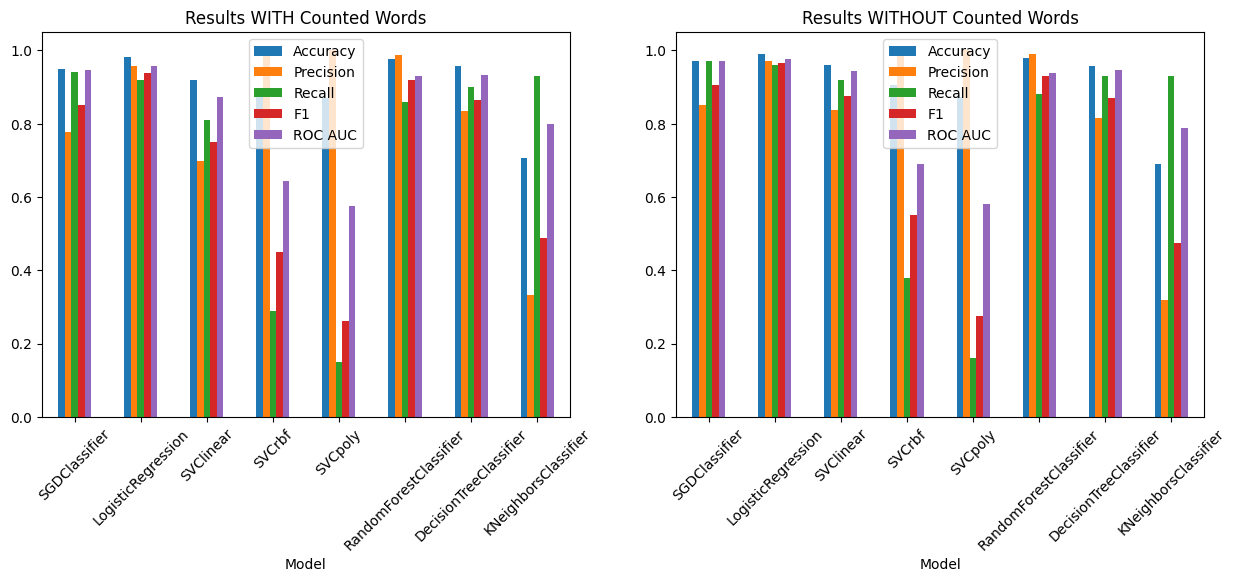

In [52]:
# final_res.plot.bar(figsize=(10, 10))
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
final_res['Results WITH Counted Words'].plot.bar(ax=ax[0], title='Results WITH Counted Words', rot=45)
final_res['Results WITHOUT Counted Words'].plot.bar(ax=ax[1], title='Results WITHOUT Counted Words', rot=45)
